In [2]:
import pandas as pd

items = pd.read_csv("../data/olist_order_items_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

df = pd.merge(items, reviews, on="order_id")
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,7b07bacd811c4117b742569b04ce3580,4,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0c5b33dea94867d1ac402749e5438e8b,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,f4028d019cb58564807486a6aaf33817,4,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,940144190dcba6351888cafa43f3a3a5,5,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59


In [3]:
customer_df = df.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum",
    "review_score": "mean"
}).reset_index()

customer_df.head()

,order_id,price,freight_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,5.0
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,4.0
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,5.0


In [4]:
features = customer_df[["price", "freight_value", "review_score"]]

In [5]:
features = features.dropna()

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

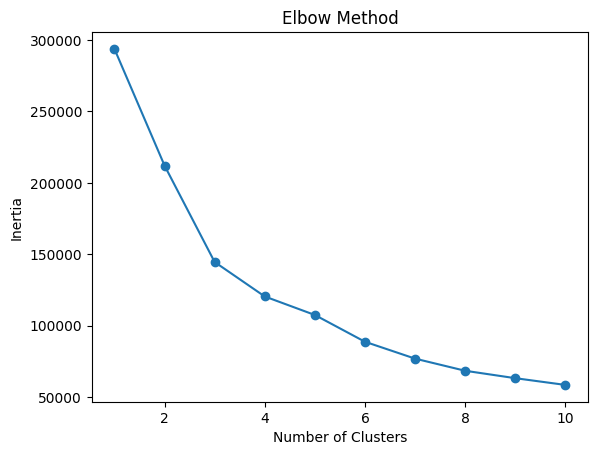

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

customer_df.head()

,order_id,price,freight_value,review_score,Cluster
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,4.0,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,5.0,1


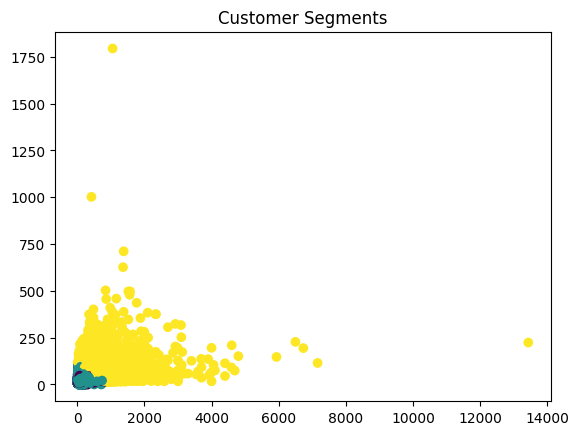

In [10]:
plt.scatter(
    customer_df["price"],
    customer_df["freight_value"],
    c=customer_df["Cluster"]
)

plt.title("Customer Segments")
plt.show()

Cluster Interpretation Section
  Cluster 0 — Low Value / Budget Customers
Low average price,
Low freight value,
Moderate review scores

  Interpretation:
These customers mostly purchase low-cost items and are highly price-sensitive.

  Business Insight:
Offer discounts and bundle deals to increase engagement.

  Cluster 1 — Regular Customers
Medium price range,
Moderate freight cost,
Balanced review scores
  
  Interpretation:
These customers shop occasionally and show stable purchasing behavior.

  Business Insight:
Use loyalty programs and personalized recommendations.

 Cluster 2 — High Value / Premium Customers
High price orders,
Higher freight value,
High review scores

  Interpretation:
These are premium customers who spend more and value quality.

  Business Insight:
Focus on premium services, fast delivery, and exclusive offers.

In [12]:
customer_df.groupby("Cluster").mean(numeric_only=True)

,price,freight_value,review_score
Cluster,,,
0,117.940707,22.614122,1.881693
1,109.281894,19.852660,4.749462
2,827.436769,85.852593,3.957100
